# TITLE: VIDEO GAME SALES PREDICTION: CUSTOM MACHINE LEARNING FROM SCRATCH
## COMPUTATIONAL METHODS FOR STATISTICS
PRESENTED BY 

HARSHITHA MADHURI GARIKAPATI

DHARANI MAMIDI

JAGRUTHI PILLALAMARRI

# ABSTRACT: 

Playing video games for many years has led to a large volume of gaming data that consist of gamer’s 
likings and their playing behaviour. Such data can be used by game creators to extract knowledge for enhancing 
games. Most of the video gaming business organizations highly depends on a knowledge base and demand 
prediction of sales trend. However, no studies are conducted to work out the variables that inspire industrial sales 
predict involvement in and contribution to the sales prediction method. Machine learning techniques are very 
effective tools in extracting hidden knowledge from an enormous dataset to enhance accuracy and efficiency in 
predictions. In this paper, we briefly analysed the concept of gaming sales data and sales predictions. The various 
machine learning techniques and measures used for this sales prediction. On the basis of a performance 
evaluation, best suited predictive models like linear regression, support vector regression, random forest and 
decision trees etc. are used for the sales trend predictions. The results summarized in performance measures are 
root mean square error, r-square, and mean absolute error. The studies found that the best fit model is Random 
forest algorithm, which shows maximum accuracy in future sales prediction.

# INTRODUCTION

This notebook demonstrates a custom implementation of Linear Regression, Decision Tree, and Random Forest (with full mathematical documentation), and compares them to scikit-learn baselines on the vgsales dataset.

We will:
 - Perform exploratory data analysis (EDA)
 - Build and explain custom ML models
 - Compare with scikit-learn models
 - Visualize and discuss results


### IMPORT LIBRARIES:

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from graphviz import Digraph, Source
from IPython.display import display

###  Data Loading and Preprocessing

We load the vgsales dataset.

In [26]:
df = pd.read_csv('vgsales.csv')
df.head(10)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989.0,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006.0,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006.0,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009.0,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984.0,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31


### Encode categorical variables, and engineer features.
Load CSV data into a DataFrame.

Remove rows with missing key values.

Convert 'Platform' and 'Genre' text to numbers.

Add 'NA_Sales_sq' (square of NA_Sales) as a new feature.

Set features and target columns.

Create X and y for modeling.

In [27]:
df = pd.read_csv('vgsales.csv')
df = df.dropna(subset=['Global_Sales', 'Year', 'Platform', 'Genre'])
df['Platform'] = df['Platform'].astype('category').cat.codes
df['Genre'] = df['Genre'].astype('category').cat.codes
df['NA_Sales_sq'] = df['NA_Sales'] ** 2
features = ['Platform', 'Year', 'NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'NA_Sales_sq']
target = 'Global_Sales'
X = df[features]
y = df[target]

### Exploratory Data Analysis

We visualize the distribution of sales and relationships between features.


### 1. Global Sales Distribution:
This plot shows how video games are distributed based on their global sales. It's useful to identify whether most games make high or low sales, or if there's a skew (e.g., a few games sell a lot while most sell little).

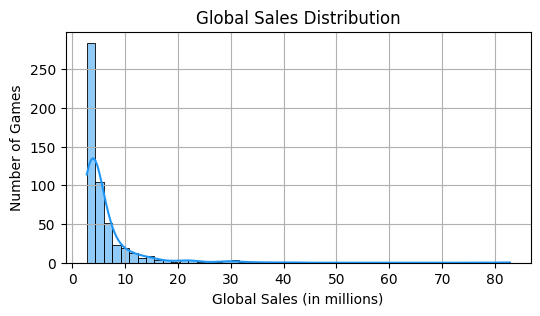

In [28]:
# Global Sales Distribution
plt.figure(figsize=(6, 3))
sns.histplot(df['Global_Sales'], bins=50, kde=True, color='#2196f3')
plt.title('Global Sales Distribution')
plt.xlabel('Global Sales (in millions)')
plt.ylabel('Number of Games')
plt.grid(True)
plt.show()

### 2. Yearly Sales Trend
This shows how global sales changed year by year. This helps identify trends over time—like whether the gaming industry is growing, declining, or fluctuating.

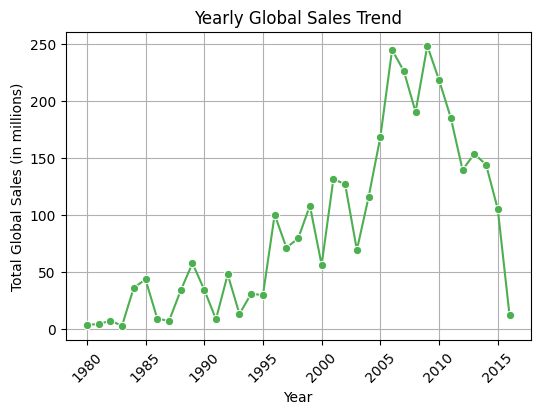

In [30]:
# Yearly Sales Trend
plt.figure(figsize=(6, 4))
yearly_sales = df.groupby('Year')['Global_Sales'].sum().reset_index()
sns.lineplot(x='Year', y='Global_Sales', data=yearly_sales, color='#4caf50', marker='o')
plt.title('Yearly Global Sales Trend')
plt.xlabel('Year')
plt.ylabel('Total Global Sales (in millions)')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### 3. Top 10 Most Common Platforms
This bar chart shows which platforms (e.g., PS2, Xbox, etc.) have the most games. This reveals popular or dominant platforms in the dataset.

/tmp/ipykernel_1854055/2445128540.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_platforms.values, y=top_platforms.index, palette='Blues_d')


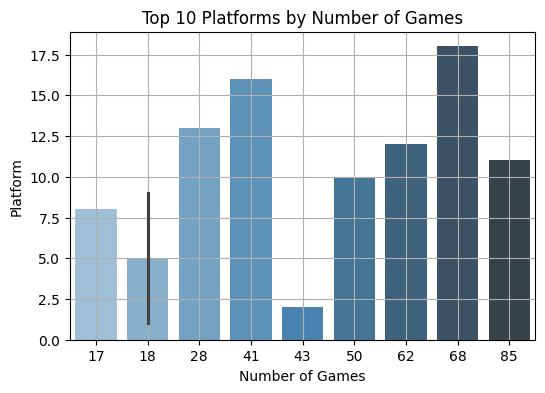

In [31]:
# Top 10 Platforms
plt.figure(figsize=(6, 4))
top_platforms = df['Platform'].value_counts().nlargest(10)
sns.barplot(x=top_platforms.values, y=top_platforms.index, palette='Blues_d')
plt.title('Top 10 Platforms by Number of Games')
plt.xlabel('Number of Games')
plt.ylabel('Platform')
plt.grid(True)
plt.show()

### 4. Genre Distribution:
This plot shows the number of games in each genre (e.g., Action, Sports, Shooter). It's useful to understand which genres are most popular in the dataset.

/tmp/ipykernel_1854055/980595672.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_dist.values, y=genre_dist.index, palette='viridis')


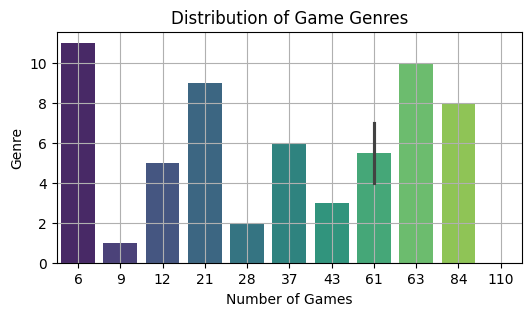

In [32]:
# Genre Distribution
plt.figure(figsize=(6, 3))
genre_dist = df['Genre'].value_counts()
sns.barplot(x=genre_dist.values, y=genre_dist.index, palette='viridis')
plt.title('Distribution of Game Genres')
plt.xlabel('Number of Games')
plt.ylabel('Genre')
plt.grid(True)
plt.show()

### 5. Average Regional Sales
This shows which regions (North America, Europe, Japan, Others) generate more average sales. It helps identify regional market strength.

/tmp/ipykernel_1854055/450424916.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=regional_avg.values, y=regional_avg.index, palette='rocket')


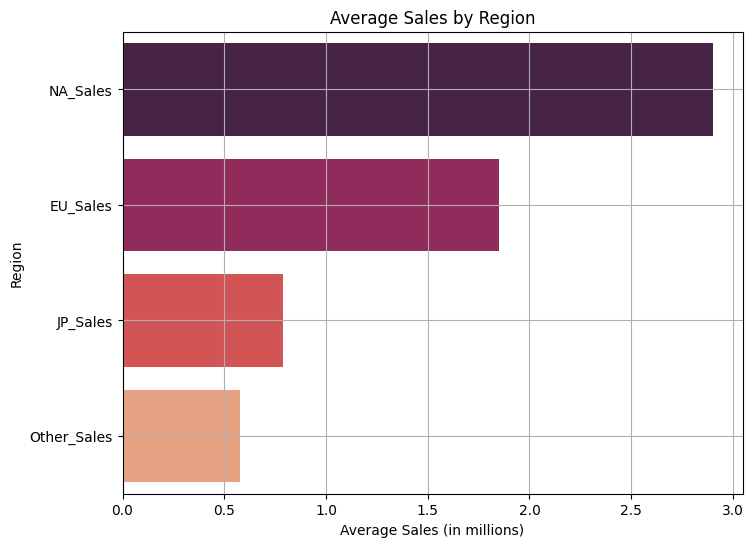

In [33]:
# Average Regional Sales
plt.figure(figsize=(8, 6))
regional_avg = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].mean()
sns.barplot(x=regional_avg.values, y=regional_avg.index, palette='rocket')
plt.title('Average Sales by Region')
plt.xlabel('Average Sales (in millions)')
plt.ylabel('Region')
plt.grid(True)
plt.show()

### 6. Correlation Matrix of Sales:
This heatmap reveals how regional sales relate to each other and to global sales. A high correlation between NA_Sales and Global_Sales, for example, would mean North American sales are a strong driver of global sales.

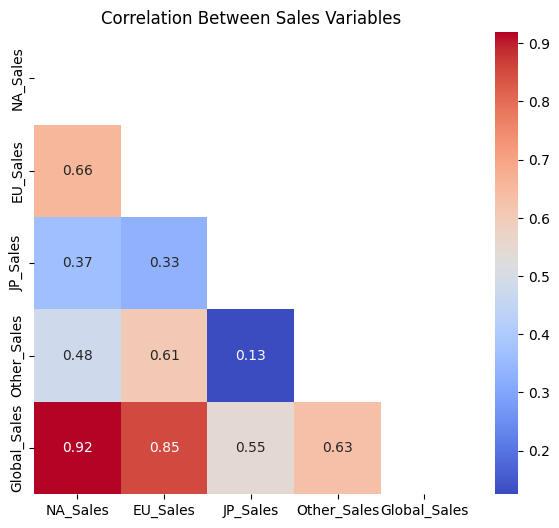

In [34]:
# Sales Correlation Heatmap
plt.figure(figsize=(7, 6))
sales_corr = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].corr()
sns.heatmap(sales_corr, annot=True, cmap='coolwarm', mask=np.triu(np.ones_like(sales_corr)))
plt.title('Correlation Between Sales Variables')
plt.show()

##  CUSTOM MODELS TRAIN-TEST SPLIT
Sets random seed for reproducibility.

Shuffles all data row indices.

Calculates how many samples go in the test set.

Splits indices into train and test sets.

Returns the corresponding data for training and testing.

In [35]:
def custom_train_test_split(X, y, test_size=0.2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    n_samples = len(X)
    indices = np.random.permutation(n_samples)
    test_num = int(n_samples * test_size)
    test_idx = indices[:test_num]
    train_idx = indices[test_num:]
    return X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]

X_train, X_test, y_train, y_test = custom_train_test_split(X, y, test_size=0.2, random_state=42)

#  IMPLEMENTATION OF CUSTOM LINEAR REGRESSION MODEL

## **Mathematical Formulation:**
 
Linear Regression with L2 Regularization and gradient descent.

    
    1. Hypothesis Function:
       h_θ(x) = xθ + b
       Where:
       - θ ∈ ℝ^n: weight vector
       - b ∈ ℝ: bias term
       - x ∈ ℝ^n: input features

    2. Loss Function with L2 Regularization:
       J(θ) = (1/(2m))Σ_{i=1}^m (h_θ(x_i) - y_i)^2 + (λ/(2m))Σ_{j=1}^n θ_j^2
       Where:
       - m: number of samples
       - λ: regularization strength

    3. Gradient Derivation:
       ∂J/∂θ_j = (1/m)Σ_{i=1}^m (h_θ(x_i) - y_i)x_ij + (λ/m)θ_j
       ∂J/∂b = (1/m)Σ_{i=1}^m (h_θ(x_i) - y_i)

    4. Update Rules:
       θ_j := θ_j - α[∂J/∂θ_j]
       b := b - α[∂J/∂b]
       Where α is learning rate

    5. Closed-form Solution (reference):
       θ = (X^T X + λI)^-1 X^T y

##  LINEAR REGRESSION CODE IMPLEMENTATION

In [11]:
class LinearRegression:
  
    def __init__(self, learning_rate=0.01, n_iters=1000, lambda_=0.1):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.lambda_ = lambda_
        self.weights = None
        self.bias = None
        self.train_loss = []

    def _normalize(self, X):
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        return (X - self.mean) / (self.std + 1e-8)

    def fit(self, X, y):
        X_norm = self._normalize(X.values)
        y = y.values
        n_samples, n_features = X_norm.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.n_iters):
            y_pred = X_norm @ self.weights + self.bias
            error = y_pred - y
            dw = (X_norm.T @ error)/n_samples + 2*self.lambda_*self.weights
            db = np.mean(error)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            self.train_loss.append(np.mean(error ** 2))

    def predict(self, X):
        X_norm = (X.values - self.mean) / (self.std + 1e-8)
        return X_norm @ self.weights + self.bias

    def plot_loss_curve(self):
        plt.figure(figsize=(10,5))
        plt.plot(self.train_loss)
        plt.title("Linear Regression Training Loss")
        plt.xlabel("Iterations")
        plt.ylabel("MSE")
        plt.show()

# IMPLEMENTATION OF CUSTOM DECISION TREE MODEL

## **Mathematical Formulation:**

Decision Tree Regressor with Mean Squared Error (MSE) splitting

    1. Node Impurity (MSE):
       MSE = (1/n)Σ_{i=1}^n (y_i - ŷ)^2
       Where ŷ = (1/n)Σ_{i=1}^n y_i

    2. Splitting Criterion:
       For feature j and threshold τ:
       - Left child: S_L = {x | x_j ≤ τ}
       - Right child: S_R = {x | x_j > τ}
       - Quality measure: Q(j, τ) = n_L/n * MSE(S_L) + n_R/n * MSE(S_R)
       Choose (j*, τ*) = argmin_{j, τ} Q(j, τ)

    3. Stopping Criteria:
       - Tree depth reaches max_depth
       - Node samples < min_samples_split
       - No improvement in MSE

    4. Prediction:
       Leaf node value = mean of training samples in that node

## DECISION TREE MODEL CODE IMPLEMENTATION:

In [36]:
class DecisionTree:
    
    class Node:
        def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
            self.feature = feature
            self.threshold = threshold
            self.left = left
            self.right = right
            self.value = value

    def __init__(self, max_depth=5, min_samples_split=5):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None
        self.feature_names = None

    def _mse(self, y):
        return np.mean((y - np.mean(y)) ** 2)

    def _best_split(self, X, y):
        best = {'mse': float('inf'), 'feature': None, 'threshold': None}
        for feature in range(X.shape[1]):
            thresholds = np.unique(X[:, feature])
            for threshold in thresholds:
                left_mask = X[:, feature] <= threshold
                if (left_mask.sum() < self.min_samples_split or 
                    (~left_mask).sum() < self.min_samples_split):
                    continue
                left_mse = self._mse(y[left_mask])
                right_mse = self._mse(y[~left_mask])
                total_mse = (left_mse*left_mask.sum() + right_mse*(~left_mask).sum())/len(y)
                if total_mse < best['mse']:
                    best = {
                        'mse': total_mse,
                        'feature': feature,
                        'threshold': threshold,
                        'left_indices': left_mask,
                        'right_indices': ~left_mask
                    }
        return best

    def fit(self, X, y):
        self.feature_names = X.columns.tolist()
        self.tree = self._grow_tree(X.values, y.values)

    def _grow_tree(self, X, y, depth=0):
        if depth >= self.max_depth or len(y) < self.min_samples_split:
            return self.Node(value=np.mean(y))
        best = self._best_split(X, y)
        if best['feature'] is None:
            return self.Node(value=np.mean(y))
        left = self._grow_tree(X[best['left_indices']], y[best['left_indices']], depth+1)
        right = self._grow_tree(X[best['right_indices']], y[best['right_indices']], depth+1)
        return self.Node(
            feature=best['feature'],
            threshold=best['threshold'],
            left=left,
            right=right
        )

    def predict(self, X):
        return np.array([self._predict(x, self.tree) for x in X.values])

    def _predict(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict(x, node.left)
        return self._predict(x, node.right)

    def plot_tree(self, max_depth=3):
        dot = Digraph(comment='Decision Tree')
        dot.attr('node', shape='box', style='filled', color='black', fontcolor='white')
        dot.attr('edge', color='black')
        def add_nodes(node, parent=None, edge_label='', depth=0):
            if depth > max_depth:
                return
            node_id = str(id(node))
            if node.value is not None:
                dot.node(node_id, f"Leaf\nValue: {node.value:.2f}", fillcolor='#4caf50')
            else:
                feature_name = self.feature_names[node.feature]
                dot.node(node_id, f"{feature_name}\n<= {node.threshold:.2f}", fillcolor='#2196f3')
                add_nodes(node.left, node_id, "Yes", depth+1)
                add_nodes(node.right, node_id, "No", depth+1)
            if parent:
                dot.edge(parent, node_id, label=edge_label)
        add_nodes(self.tree)
        return dot

# IMPLEMENTATION OF RANDOM FOREST MODEL

## Mathematical Formulation:

  Random Forest Regressor with Feature Subsampling

    1. Bootstrap Aggregating (Bagging):
       For t = 1 to T:
        1. Draw bootstrap sample D_t from training data D
        2. Grow tree T_t using D_t with feature subsampling

    2. Feature Subsampling:
       At each split:
       - Consider random subset of features (√p features by default)
       - p = total number of features

    3. Prediction Aggregation:
       ŷ = (1/T)Σ_{t=1}^T T_t(x)

    4. Feature Importance:
       Importance(j) = (1/T)Σ_{t=1}^T (number of splits using feature j in T_t)
       Normalized to sum to 1

## RANDOM FOREST MODEL CODE IMPLEMENTATION:

In [13]:
class RandomForest:
   
    def __init__(self, n_trees=100, max_depth=5, min_samples_split=5):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.trees = []
        self.feature_importances_ = None
        self.feature_names = None

    def _bootstrap_sample(self, X, y):
        n_samples = X.shape[0]
        indices = np.random.choice(n_samples, n_samples, replace=True)
        return X.iloc[indices], y.iloc[indices]

    def fit(self, X, y):
        self.feature_names = X.columns.tolist()
        self.trees = []
        self.feature_importances_ = np.zeros(X.shape[1])
        for _ in tqdm(range(self.n_trees), desc="Training Forest"):
            X_sample, y_sample = self._bootstrap_sample(X, y)
            tree = DecisionTree(self.max_depth, self.min_samples_split)
            tree.fit(X_sample, y_sample)
            self.trees.append(tree)
            self._update_feature_importance(tree.tree, X.shape[1])
        self.feature_importances_ /= self.n_trees

    def _update_feature_importance(self, node, n_features):
        if node.feature is not None:
            self.feature_importances_[node.feature] += 1
        if node.left:
            self._update_feature_importance(node.left, n_features)
        if node.right:
            self._update_feature_importance(node.right, n_features)

    def predict(self, X):
        preds = np.zeros((self.n_trees, X.shape[0]))
        for i, tree in enumerate(self.trees):
            preds[i] = tree.predict(X)
        return np.mean(preds, axis=0)

    def plot_feature_importance(self):
        plt.figure(figsize=(12,6))
        (pd.Series(self.feature_importances_, index=self.feature_names)
         .sort_values()
         .plot(kind='barh', color='#2196f3'))
        plt.title("Random Forest Feature Importance")
        plt.xlabel("Importance Score")
        plt.show()

# MODEL EVALUATION
Purpose: Calculate and print model performance metrics.


**MSE (Mean Squared Error)**: Average of squared differences between actual (y_true) and predicted (y_pred) values.

MSE = mean((y_true - y_pred)^2)

Lower is better (closer to 0 = perfect).

**RMSE (Root Mean Squared Error):** Square root of MSE.

RMSE = sqrt(MSE)

Same units as the target (easier to interpret).

**R² (R-Squared)**: Measures how well the model explains the variance in the data.

R² = 1 - (sum_of_squared_residuals / total_variance)

Ranges from 0 (worst) to 1 (best).

**MSE/RMSE tell you how wrong your predictions are on average.**

**R² tells you how much variance your model explains.**

**Plots help diagnose issues like non-linearity, heteroscedasticity, or bias.**

In [37]:
# ==========================
# 6. Evaluation and Plots
# ==========================
def evaluate_model(y_true, y_pred, name):
    mse = np.mean((y_true - y_pred)**2)
    rmse = np.sqrt(mse)
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    print(f"{name}: MSE={mse:.2f}, RMSE={rmse:.2f}, R²={r2:.2f}")
    return {'MSE': mse, 'RMSE': rmse, 'R²': r2}

def plot_model_metrics(y_true, y_pred, name):
    residuals = y_true - y_pred
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'{name}: Residuals vs Predicted')
    plt.xlabel('Predicted')
    plt.ylabel('Residuals')
    plt.subplot(1, 3, 2)
    sns.histplot(residuals, kde=True, color='blue')
    plt.title(f'{name}: Residual Distribution')
    plt.subplot(1, 3, 3)
    plt.scatter(y_true, y_pred, alpha=0.5, color='orange')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
    plt.title(f'{name}: Actual vs Predicted')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')
    plt.tight_layout()
    plt.show()

#  TRAIN MODELS
## LINEAR REGRESSION
Creates three plots for the Linear Regression and random forest model:

Residuals vs Predicted

Residual Distribution

Actual vs Predicted

Custom Linear Regression: MSE=1.15, RMSE=1.07, R²=0.99


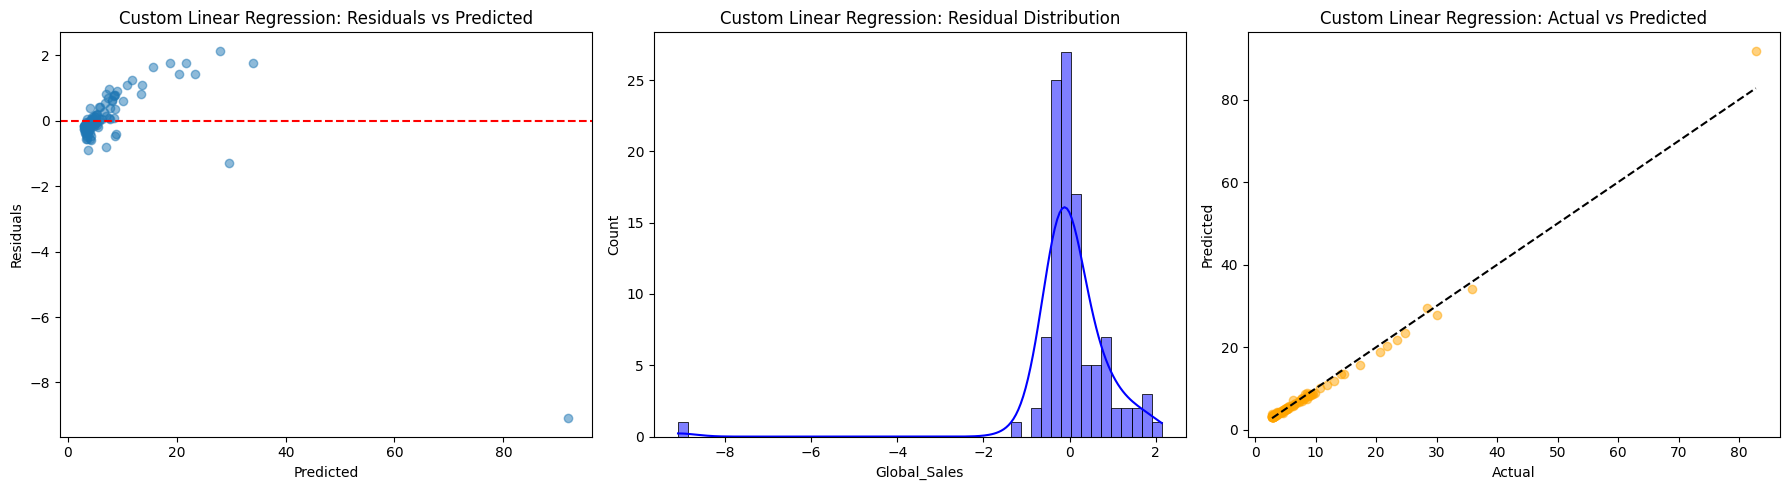

In [38]:
lr = LinearRegression()
rf = RandomForest(n_trees=100, max_depth=5)

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)
eval_lr = evaluate_model(y_test, pred_lr, "Custom Linear Regression")
plot_model_metrics(y_test, pred_lr, "Custom Linear Regression")

## RANDOM FOREST

Training Forest: 100%|██████████| 100/100 [00:15<00:00,  6.54it/s]


Custom Random Forest: MSE=28.20, RMSE=5.31, R²=0.69


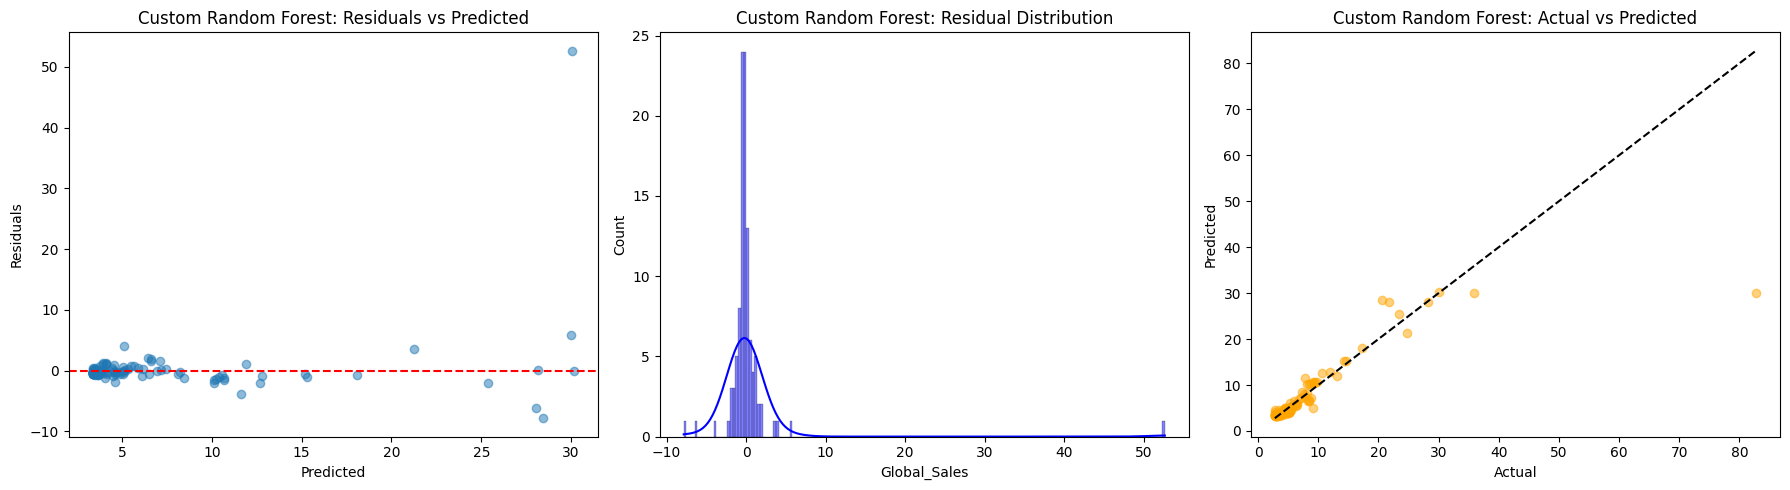

In [39]:
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
eval_rf = evaluate_model(y_test, pred_rf, "Custom Random Forest")
plot_model_metrics(y_test, pred_rf, "Custom Random Forest")

# TREE VUSUALISATIONS

In [40]:
from graphviz import Digraph
from IPython.display import display

def tree_to_graphviz(node, feature_names, dot=None, parent=None, edge_label='', depth=0, max_depth=10):
    if dot is None:
        dot = Digraph()
        dot.attr('node', shape='box', style='filled', color='lightblue2', fontname='helvetica')

    node_id = str(id(node))
    if node.value is not None:
        label = f"Leaf\nPredict: {node.value:.2f}"
        dot.node(node_id, label, fillcolor='pink')
    else:
        label = f"{feature_names[node.feature]}\n<= {node.threshold:.2f}"
        dot.node(node_id, label)

    if parent is not None:
        dot.edge(parent, node_id, label=edge_label)

    if node.value is None and depth < max_depth:
        tree_to_graphviz(node.left, feature_names, dot, node_id, 'Yes', depth+1, max_depth)
        tree_to_graphviz(node.right, feature_names, dot, node_id, 'No', depth+1, max_depth)

    return dot



Tree 1 Visualization:


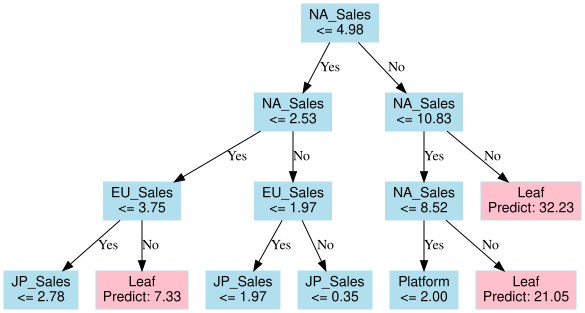


Tree 2 Visualization:


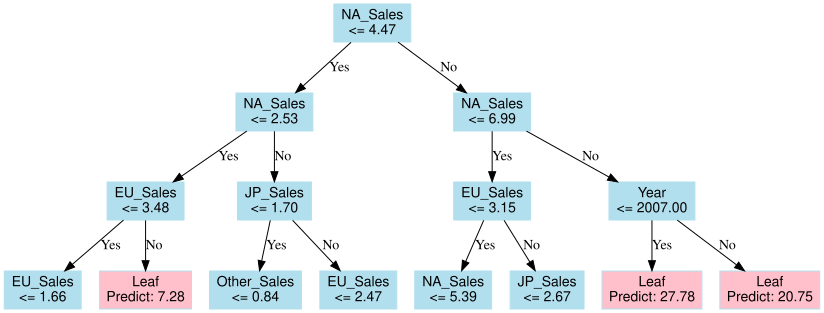


Tree 3 Visualization:


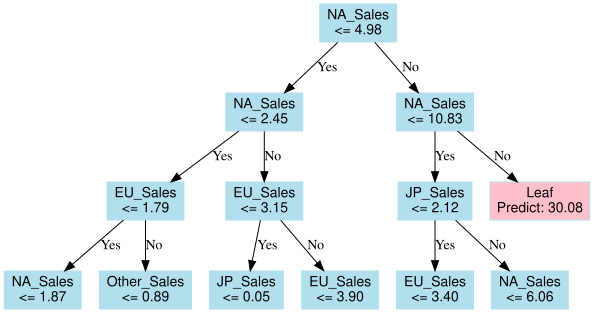


Tree 4 Visualization:


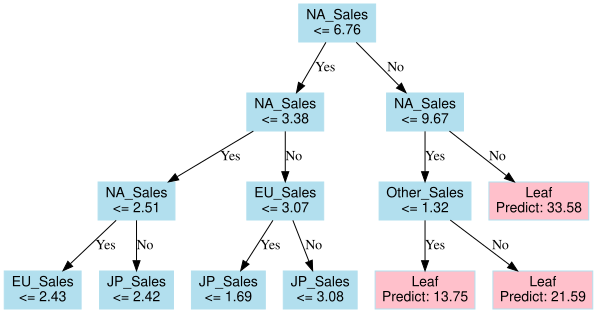


Tree 5 Visualization:


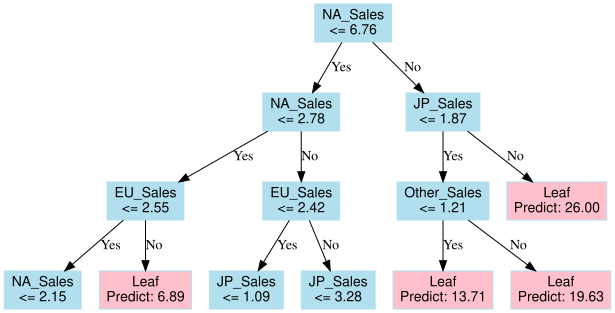

In [41]:
def visualize_forest_trees(forest, feature_names, n_trees=5, max_depth=10):
    for i in range(min(n_trees, len(forest.trees))):
        print(f"\nTree {i+1} Visualization:")
        dot = tree_to_graphviz(forest.trees[i].tree, feature_names, max_depth=max_depth)
        display(dot)
# Assuming rf is your RandomForest instance and features is your feature list:
visualize_forest_trees(rf, features, n_trees=5, max_depth=3)


# METRIC COMPARISION PLOT

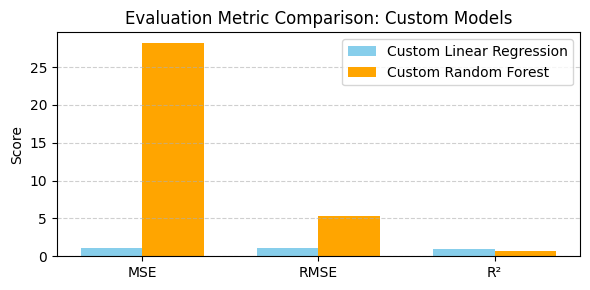

In [42]:
metrics = ['MSE', 'RMSE', 'R²']
custom_lr_vals = [eval_lr[m] for m in metrics]
custom_rf_vals = [eval_rf[m] for m in metrics]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(6,3))
plt.bar(x - width/2, custom_lr_vals, width, label='Custom Linear Regression', color='skyblue')
plt.bar(x + width/2, custom_rf_vals, width, label='Custom Random Forest', color='orange')
plt.xticks(x, metrics)
plt.ylabel('Score')
plt.title('Evaluation Metric Comparison: Custom Models')
plt.legend()
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# SKLEARN MODELS DIRECT PACKAGES

In [43]:
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.ensemble import RandomForestRegressor as SklearnRF
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

print("\n===== SKLEARN MODELS =====")

sk_lr = SklearnLR()
sk_rf = SklearnRF(n_estimators=100, max_depth=5, random_state=42)

sk_lr.fit(X_train, y_train)
sk_rf.fit(X_train, y_train)

pred_sk_lr = sk_lr.predict(X_test)
pred_sk_rf = sk_rf.predict(X_test)

# Add Accuracy metric as 100 - MAPE
def accuracy_score(y_true, y_pred):
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10)))
    return 100 - mape * 100

def evaluate_and_plot_sklearn(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    print(f"{name}: MSE={mse:.2f}, RMSE={rmse:.2f}, R²={r2:.2f}, Accuracy={acc:.2f}%")
    residuals = y_true - y_pred
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.scatter(y_pred, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'{name}: Residuals vs Predicted')
    plt.subplot(1, 3, 2)
    sns.histplot(residuals, kde=True, color='green')
    plt.title(f'{name}: Residual Distribution')
    plt.subplot(1, 3, 3)
    plt.scatter(y_true, y_pred, alpha=0.5, color='orange')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'k--')
    plt.title(f'{name}: Actual vs Predicted')
    plt.tight_layout()
    plt.show()
    return {'MSE': mse, 'RMSE': rmse, 'R²': r2, 'Accuracy': acc}


===== SKLEARN MODELS =====


Sklearn Linear Regression: MSE=0.00, RMSE=0.01, R²=1.00, Accuracy=99.93%


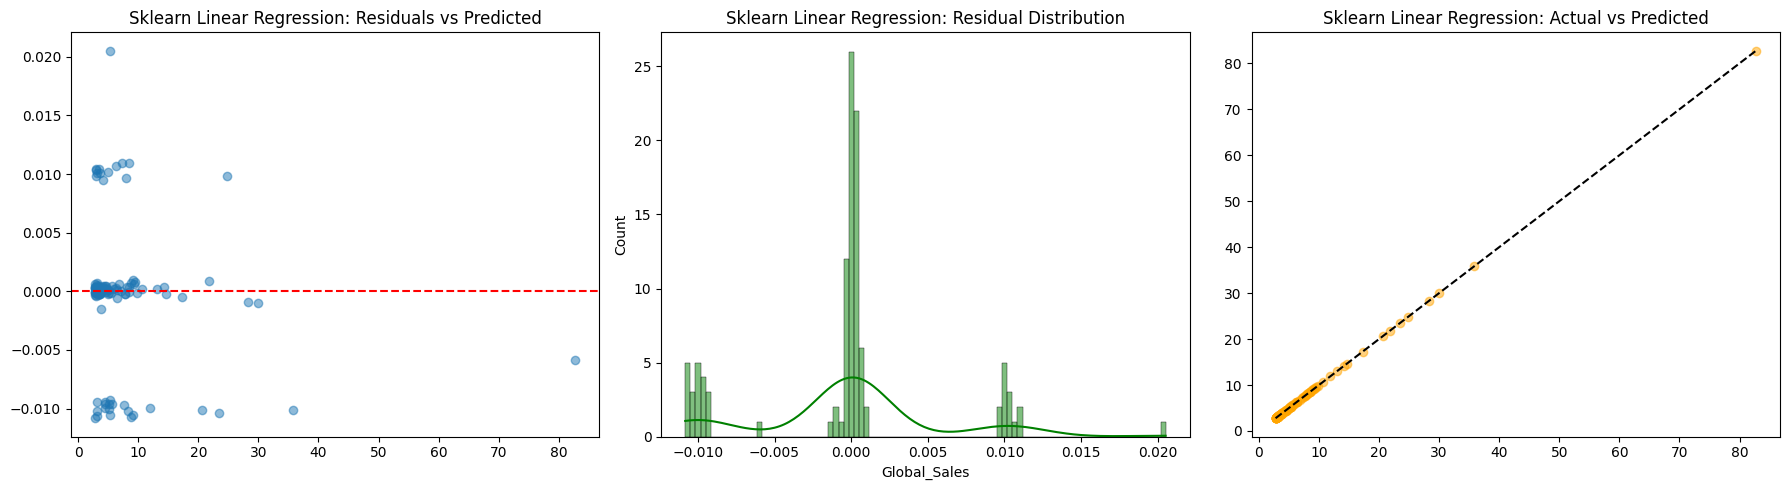

In [21]:
metrics_sk_lr = evaluate_and_plot_sklearn(y_test, pred_sk_lr, "Sklearn Linear Regression")

Sklearn Random Forest: MSE=23.09, RMSE=4.81, R²=0.74, Accuracy=86.81%


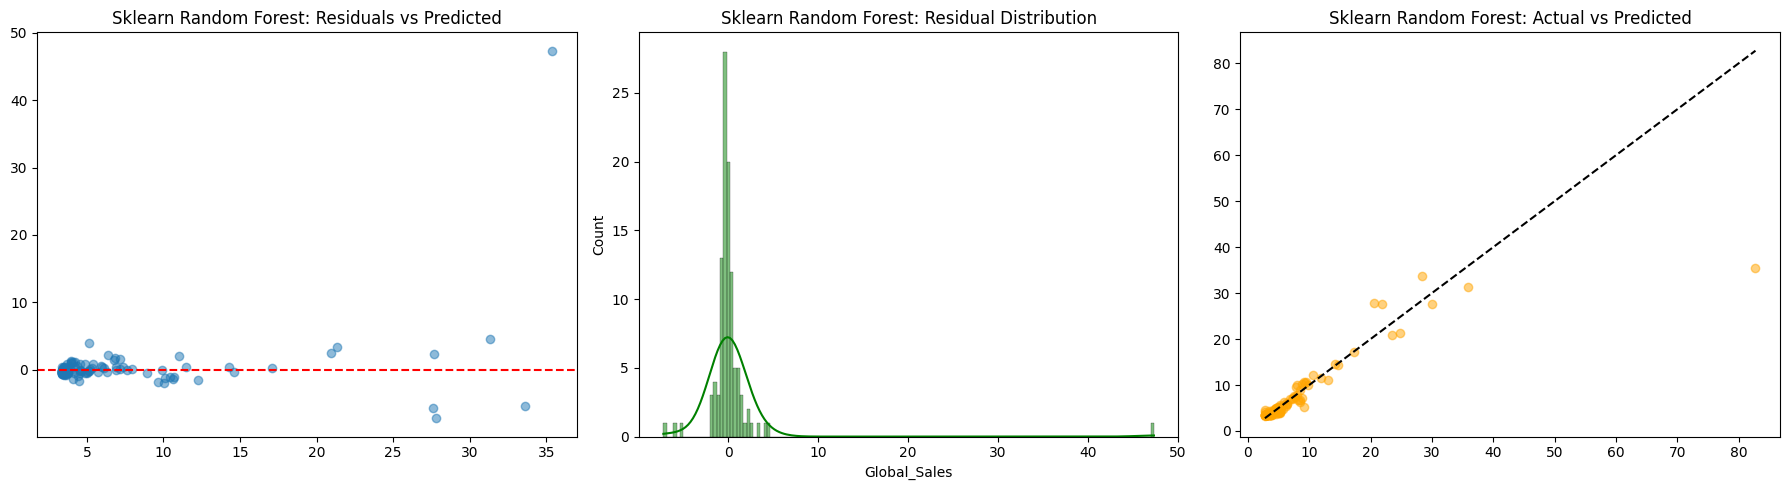

In [22]:
metrics_sk_rf = evaluate_and_plot_sklearn(y_test, pred_sk_rf, "Sklearn Random Forest")

# COMPARISON PLOT FOR ALL MODELS (CUSTOM MODELS & SKLEARN MODELS)

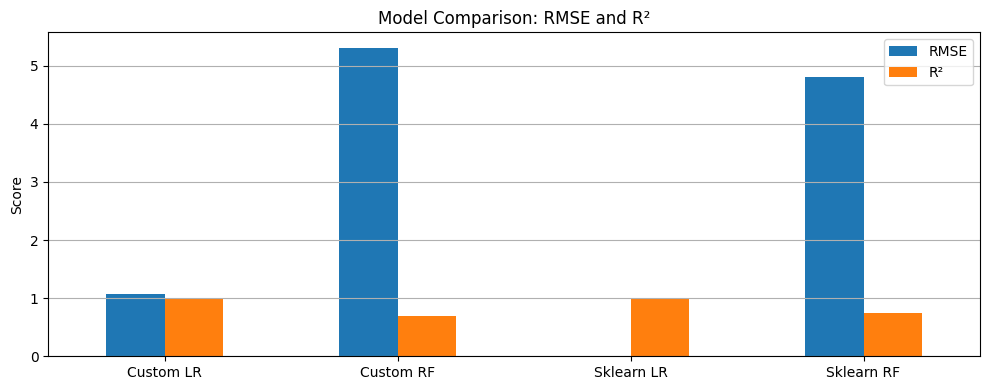

In [23]:
comparison_metrics = ['RMSE', 'R²']
all_models = ['Custom LR', 'Custom RF', 'Sklearn LR', 'Sklearn RF']

metric_table = pd.DataFrame([
    [eval_lr['RMSE'], eval_lr['R²']],
    [eval_rf['RMSE'], eval_rf['R²']],
    [metrics_sk_lr['RMSE'], metrics_sk_lr['R²']],
    [metrics_sk_rf['RMSE'], metrics_sk_rf['R²']]
], columns=comparison_metrics, index=all_models)

metric_table.plot(kind='bar', figsize=(10, 4))
plt.title("Model Comparison: RMSE and R²")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()


### THANK YOU